In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## Load data

In [2]:
df = pd.read_csv('anshika_customer_segmentation_dataset.csv')
df.head()

,customer_id,age,annual_income,spending_score,visit_frequency
0,1,24,53698.91,40,5
1,2,24,59056.22,96,4
2,3,55,74520.56,33,8
3,4,41,65401.55,16,11
4,5,45,43415.91,55,5


In [3]:
df.describe()

,customer_id,age,annual_income,spending_score,visit_frequency
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,40.776667,55938.791133,48.820000,7.900000
std,86.746758,14.313971,17332.560915,29.596522,2.745017
min,1.000000,18.000000,15000.000000,1.000000,3.000000
25%,75.750000,28.000000,44859.007500,21.000000,6.000000
50%,150.500000,41.000000,57215.915000,48.000000,8.000000
75%,225.250000,54.000000,65555.207500,74.250000,10.000000
max,300.000000,64.000000,120224.220000,98.000000,17.000000


## Feature selection and scaling

In [4]:
features = ['age', 'annual_income', 'spending_score', 'visit_frequency']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow method to choose k

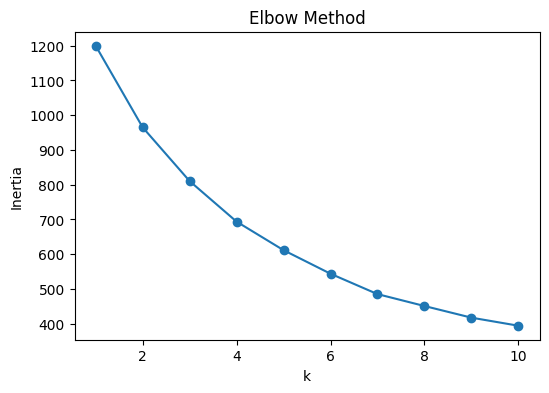

In [5]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## Fit K-Means

In [6]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,customer_id,age,annual_income,spending_score,visit_frequency,cluster
0,1,24,53698.91,40,5,2
1,2,24,59056.22,96,4,2
2,3,55,74520.56,33,8,0
3,4,41,65401.55,16,11,3
4,5,45,43415.91,55,5,1


## Visualize clusters

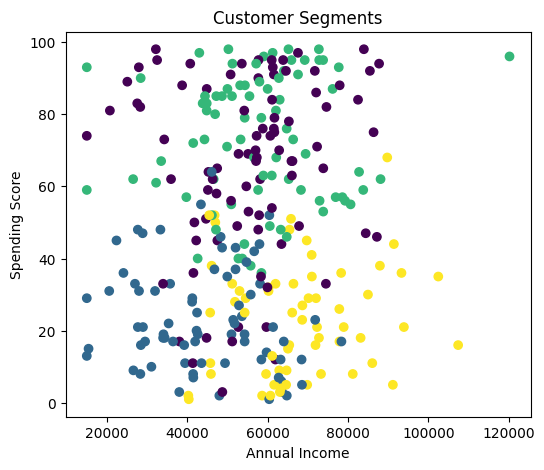

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(df['annual_income'], df['spending_score'], c=df['cluster'], cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

## Cluster summary

In [8]:
df.groupby('cluster')[features].mean()

,age,annual_income,spending_score,visit_frequency
cluster,,,,
0,52.976744,55592.525000,65.976744,9.883721
1,46.432432,44625.046892,23.594595,6.081081
2,29.924051,57915.674430,73.037975,6.392405
3,30.770492,67591.613770,23.868852,9.262295
